# Covertype Classification using Logistic Regression and LIME

## Objective

The objective of this activity is to train a Logistic Regression model using the Covertype dataset to predict forest cover type from cartographic and environmental features. 

The general performance of the model will be evaluated using accuracy, precision, recall, F1-score and a confusion matrix. Explainable AI techniques will then be used to investigate how the model makes its predictions. LIME will be used for a local explanation, while Logistic Regression coefficients will be examined as a global explanation.

# 1. Setup

In [78]:
# If needed:
%pip install scikit-learn pandas matplotlib lime

Note: you may need to restart the kernel to use updated packages.


In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# 2. Load and Explore the Dataset

In [80]:
covtype = fetch_covtype(as_frame=True)

X = covtype.data
y = covtype.target

print("Dataset shape:", X.shape)
print("\nTarget distribution:")
print(y.value_counts().sort_index())

X.head()

Dataset shape: (581012, 54)

Target distribution:
Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [81]:
print(X.columns.tolist())

['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area_0', 'Wilderness_Area_1', 'Wilderness_Area_2', 'Wilderness_Area_3', 'Soil_Type_0', 'Soil_Type_1', 'Soil_Type_2', 'Soil_Type_3', 'Soil_Type_4', 'Soil_Type_5', 'Soil_Type_6', 'Soil_Type_7', 'Soil_Type_8', 'Soil_Type_9', 'Soil_Type_10', 'Soil_Type_11', 'Soil_Type_12', 'Soil_Type_13', 'Soil_Type_14', 'Soil_Type_15', 'Soil_Type_16', 'Soil_Type_17', 'Soil_Type_18', 'Soil_Type_19', 'Soil_Type_20', 'Soil_Type_21', 'Soil_Type_22', 'Soil_Type_23', 'Soil_Type_24', 'Soil_Type_25', 'Soil_Type_26', 'Soil_Type_27', 'Soil_Type_28', 'Soil_Type_29', 'Soil_Type_30', 'Soil_Type_31', 'Soil_Type_32', 'Soil_Type_33', 'Soil_Type_34', 'Soil_Type_35', 'Soil_Type_36', 'Soil_Type_37', 'Soil_Type_38', 'Soil_Type_39']


## Dataset Description 

The Forest Covertype dataset contains cartographic information collected from forested areas in the Roosevelt National Forest in Colorado. 

The objective is to predict the dominant forest cover type of an area using geographical and environmental characteristics. 

The dataset contains 581,012 observations and 54 input features. 

The first 10 features are numerical variables describing characteristics such as:
- Elevation
- Aspect
- Slope
- Distance to hydrology
- Distance to roads
- Hillshade
- Distance to fire ignition points

The remaining 44 features are binary variables representing four wilderness areas and 40 soil types.

The target variable contains seven possible forest cover types, making this a multiclass classification problem.

| Class | Forest Cover Type |
|---|---|
| 1 | Spruce/Fir |
| 2 | Lodgepole Pine |
| 3 | Ponderosa Pine |
| 4 | Cottonwood/Willow |
| 5 | Aspen |
| 6 | Douglas-fir |
| 7 | Krummholz |

# 3. Train/Test Split

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (464809, 54)
Testing: (116203, 54)


### Train/Test Split

The dataset was divided into 80% training data and 20% testing data. Stratified sampling was used so that the distribution of the seven forest cover classes remained approximately the same in both sets. 

This resulted in 464,809 training observations and 116,203 testing observations.

# 4. Preprocessing and Feature Scaling

In [83]:
numeric_features = X.columns[:10]

print(numeric_features)

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points'],
      dtype='str')


In [84]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features)
    ],
    remainder="passthrough"
)

### Feature Scaling

The ten numerical features were standardised using StandardScaler. Standardisation is useful for Logistic Regression because the numerical features are measured on very different scales. 

The wilderness area and soil type features are already binary variables, so they were left unchanged.

# Train the Logistic Regression Model

In [85]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        solver="lbfgs"
    ))
])

In [86]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](7,)","[1,2,3,...,5,6,7]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](54,)","['Elevation','Aspect','Slope',...,'Soil_Type_37','Soil_Type_38', 'Soil_Type_39']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,54
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pass

## Logistic Regression Model

Logistic Regression was selected as the classification model. Although Logistic Regression is commonly introduced as a binary classifier, it can also be used for multiclass classification. 

The preprocessing and Logistic Regression model were combined into a pipeline so that the same preprocessing operations were consistently applied during training and testing.

# 6. Evaluate Model Performance

In [87]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7234408750204384


In [88]:
class_names = [
    "Spruce/Fir",
    "Lodgepole Pine",
    "Ponderosa Pine",
    "Cottonwood/Willow",
    "Aspen",
    "Douglas-fir",
    "Krummholz"
]

print(f"Accuracy: {accuracy:.4f}")

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

Accuracy: 0.7234
                   precision    recall  f1-score   support

       Spruce/Fir       0.71      0.70      0.70     42368
   Lodgepole Pine       0.75      0.80      0.77     56661
   Ponderosa Pine       0.68      0.80      0.73      7151
Cottonwood/Willow       0.60      0.43      0.50       549
            Aspen       0.17      0.01      0.01      1899
      Douglas-fir       0.49      0.27      0.35      3473
        Krummholz       0.73      0.56      0.63      4102

         accuracy                           0.72    116203
        macro avg       0.59      0.51      0.53    116203
     weighted avg       0.71      0.72      0.71    116203



## Model Performance Analysis

The Logistic Regression model achieved an overall accuracy of approximately 72.34% on the test set. 

The weighted-average F1-score was 0.71, indicating reasonable overall performance. However, performance differed considerably between forest cover types:
- Spruce/Fir: F1 ≈ 0.70
- Lodgepole Pine: F1 ≈ 0.77
- Ponderosa Pine: F1 ≈ 0.73
- Cottonwood/Willow: F1 ≈ 0.50
- Aspen: F1 ≈ 0.01
- Douglas-fir: F1 ≈ 0.35
- Krummholz: F1 ≈ 0.63 

The macro-average F1-score was 0.53, compared with a weighted-average F1-score of 0.71. This gap shows that the model performs much better on some classes than others, particularly the larger classes. 

Therefore, accuracy alone does not fully describe this model's performance.

## Confusion matrix

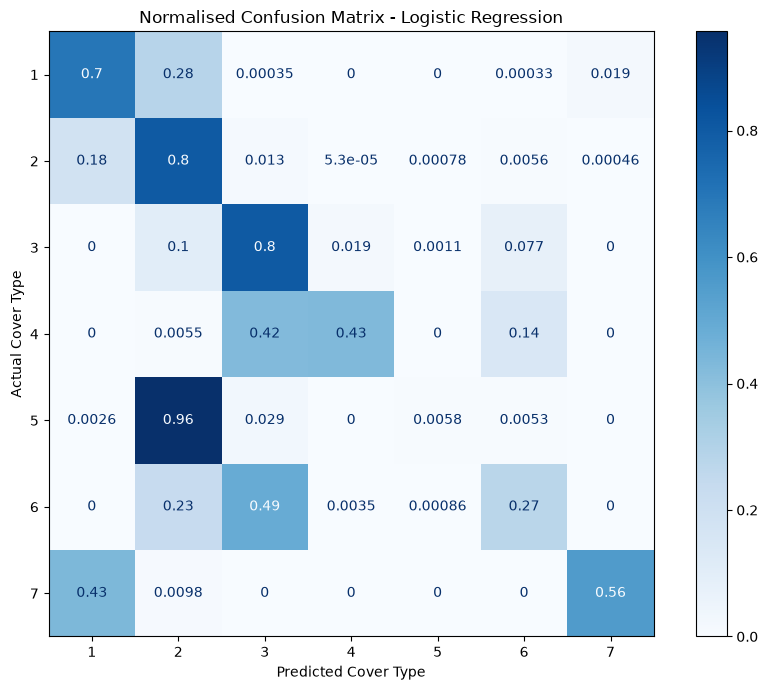

In [89]:
fig, ax = plt.subplots(figsize=(9, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[1, 2, 3, 4, 5, 6, 7],
    normalize="true",
    cmap="Blues",
    ax=ax
)

plt.title("Normalised Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Cover Type")
plt.ylabel("Actual Cover Type")
plt.tight_layout()
plt.show()


### Confusion Matrix Analysis

The normalised confusion matrix shows which forest cover types the model identifies correctly and which classes it tends to confuse. 

The matrix supports the classification report: the model performs relatively well on the larger classes, particularly Spruce/Fir, Lodgepole Pine and Ponderosa Pine, while several smaller classes are harder to distinguish. 

The dataset is strongly imbalanced and Logistic Regression uses linear decision boundaries, so both are plausible contributors to the uneven class performance. This experiment does not by itself prove which factor is responsible.

# 7. Local Explainability with LIME

In [90]:
try:
    from lime.lime_tabular import LimeTabularExplainer
except ModuleNotFoundError:
    %pip install lime
    from lime.lime_tabular import LimeTabularExplainer

In [91]:
# LIME will explain the original (unscaled) feature values so the result is easier to read.
# The first 10 features are continuous; the remaining 44 are binary indicators.
categorical_feature_indices = list(range(10, X.shape[1]))

categorical_names = {
    i: ["No", "Yes"] for i in categorical_feature_indices
}

In [92]:
# A representative sample is enough for LIME's background distribution
# and avoids unnecessarily storing all 464,809 training rows.
lime_background = X_train.sample(
    n=min(50000, len(X_train)),
    random_state=42
)

print("LIME background shape:", lime_background.shape)


LIME background shape: (50000, 54)


In [93]:
explainer = LimeTabularExplainer(
    training_data=lime_background.to_numpy(),
    feature_names=X.columns.tolist(),
    class_names=class_names,
    categorical_features=categorical_feature_indices,
    categorical_names=categorical_names,
    mode="classification",
    random_state=42
)

In [94]:
# LIME supplies NumPy arrays, while the model pipeline was trained with named columns.
def predict_proba_raw(data):
    data_df = pd.DataFrame(data, columns=X.columns)
    return model.predict_proba(data_df)


## Explain One Correct Spruce/Fir Prediction

In [95]:
# Select the first test observation that is truly Spruce/Fir (Class 1)
# and was also correctly predicted as Spruce/Fir.
matching_rows = np.where(
    (y_test.to_numpy() == 1) &
    (y_pred == 1)
)[0]

instance_number = matching_rows[0]
instance = X_test.iloc[instance_number].to_numpy()

actual = y_test.iloc[instance_number]
prediction = model.predict(X_test.iloc[[instance_number]])[0]

print("Test row:", instance_number)
print("Actual class:", actual, "-", class_names[int(actual) - 1])
print("Predicted class:", prediction, "-", class_names[int(prediction) - 1])


Test row: 0
Actual class: 1 - Spruce/Fir
Predicted class: 1 - Spruce/Fir


In [96]:
# predict_proba columns follow model.classes_, so find the probability-column index
# corresponding to the predicted class.
predicted_class_index = np.where(
    model.named_steps["classifier"].classes_ == prediction
)[0][0]

print("Class being explained:", class_names[predicted_class_index])


Class being explained: Spruce/Fir


In [97]:
explanation = explainer.explain_instance(
    instance,
    predict_proba_raw,
    labels=[predicted_class_index],
    num_features=10,
    num_samples=5000
)

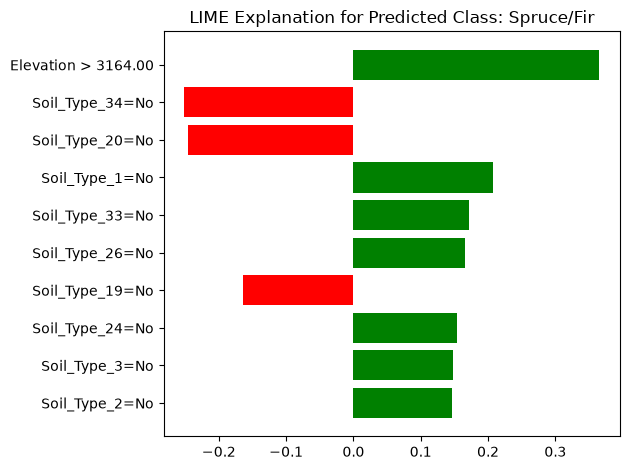

In [98]:
fig = explanation.as_pyplot_figure(
    label=predicted_class_index
)

plt.title(
    f"LIME Explanation for Predicted Class: "
    f"{class_names[predicted_class_index]}"
)
plt.tight_layout()
plt.show()


## LIME Feature Contributions

In [99]:
lime_contributions = explanation.as_list(
    label=predicted_class_index
)

for feature, importance in lime_contributions:
    print(f"{feature}: {importance:.4f}")


Elevation > 3164.00: 0.3653
Soil_Type_34=No: -0.2510
Soil_Type_20=No: -0.2462
Soil_Type_1=No: 0.2080
Soil_Type_33=No: 0.1710
Soil_Type_26=No: 0.1664
Soil_Type_19=No: -0.1634
Soil_Type_24=No: 0.1535
Soil_Type_3=No: 0.1477
Soil_Type_2=No: 0.1471


## What LIME Is Showing
LIME (Local Interpretable Model-agnostic Explanations) is used here to explain one individual prediction made by the trained Logistic Regression pipeline. 

LIME creates perturbed samples around the selected observation, asks the model for predictions on those samples, and fits a simpler interpretable model in that local neighbourhood. The resulting weights show which features locally increased or decreased support for the class being explained. 

This is a local explanation. It describes the model's behaviour around this particular observation and should not be interpreted as a global statement about every prediction in the dataset.

## LIME Findings
The selected test observation is a correctly classified Spruce/Fir (Class 1) example.

The LIME plot and printed weights above show the ten features with the strongest local influence on this prediction. Positive weights support the Spruce/Fir prediction locally, while negative weights work against it. 

The explanation allows the prediction to be examined in terms of understandable cartographic features such as elevation, wilderness area and soil type. The exact features and weights should be taken from the output above after running the notebook. 

Because LIME is local, these feature contributions apply to this observation and should not be assumed to have the same importance for every Spruce/Fir prediction.

# 8. Global Explainability with Logistic Regression Coefficients

In [100]:
classifier = model.named_steps["classifier"]

transformed_feature_names = (
    model.named_steps["preprocessor"]
    .get_feature_names_out()
)

# Remove ColumnTransformer prefixes to make the table easier to read.
clean_feature_names = [
    name.replace("numeric__", "").replace("remainder__", "")
    for name in transformed_feature_names
]

coefficients = pd.DataFrame(
    classifier.coef_,
    columns=clean_feature_names,
    index=class_names
)

coefficients


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39
Spruce/Fir,3.334081,-0.169769,0.010826,-0.225067,-0.237978,-0.482700,-0.331855,-0.317092,0.147608,-0.253763,...,1.225525,-0.029348,1.133613,-1.304836,0.599573,-1.485613,-2.923873,0.112766,0.380091,0.251238
Lodgepole Pine,0.997180,-0.151615,0.112844,0.182109,-0.177293,-0.328820,-0.599570,0.443429,-0.425081,-0.306722,...,1.437922,0.649937,1.342284,0.868827,-1.743997,0.808927,-0.372527,-0.684018,-1.110818,-0.532343
Ponderosa Pine,-3.557388,0.165404,0.014323,0.887545,0.051355,0.054268,-0.907168,0.756901,-1.144966,-0.489315,...,-1.961968,1.025316,-2.740755,-0.518371,-0.004569,-0.000407,-0.000408,-0.034398,-0.063008,-0.022437
Cottonwood/Willow,-5.047861,0.034468,-0.365344,-0.500448,0.619491,2.323899,-0.328367,1.168049,-1.387198,1.251574,...,-0.193245,-0.300039,-0.346140,-0.014184,-0.008141,-0.000473,-0.000942,-0.060633,-0.059449,-0.034330
Aspen,0.224973,0.201552,0.199702,-0.038209,0.103711,-1.070924,0.147701,0.115463,-0.152840,-0.497969,...,1.155906,0.249488,0.654894,0.139542,-0.073267,-0.015048,-0.001756,-0.391651,-0.675501,-0.214384
Douglas-fir,-3.282390,0.037076,0.341297,0.324728,-0.041050,0.183892,2.866715,-2.205451,3.864763,0.072464,...,-0.571426,0.709856,0.705415,1.006158,-0.006457,-0.000323,-0.000692,-0.047850,-0.086596,-0.027466
Krummholz,7.331404,-0.117116,-0.313648,-0.630658,-0.318237,-0.679615,-0.847456,0.038700,-0.902286,0.223731,...,-1.092715,-2.305211,-0.749311,-0.177137,1.236857,0.692937,3.300198,1.105784,1.615282,0.579721


In [101]:
spruce_coefficients = (
    coefficients.loc["Spruce/Fir"]
    .sort_values(key=abs, ascending=False)
    .head(10)
)

spruce_coefficients


Wilderness_Area_0    3.340651
Elevation            3.334081
Soil_Type_36        -2.923873
Soil_Type_1         -2.447387
Soil_Type_8          2.136837
Soil_Type_3         -2.061868
Soil_Type_20         2.036136
Soil_Type_21         1.925533
Soil_Type_19         1.543068
Soil_Type_11         1.541450
Name: Spruce/Fir, dtype: float64

### Global Explanation Findings
Logistic Regression is relatively interpretable because its learned coefficients can be inspected directly. These coefficients provide a global view of the model rather than explaining a single observation. 

The table above lists the ten largest coefficients by absolute magnitude for the Spruce/Fir class. A positive coefficient raises the model's linear score for Spruce/Fir as that feature increases or is present, while a negative coefficient lowers that score, with the other features held fixed. 

The coefficient magnitudes should be interpreted carefully because they describe the fitted model rather than proving a real-world causal relationship.

# 9. Local vs Global Explainability 

The two explanation approaches answer different questions:
- LIME is local: it explains why the model made one particular prediction.
- Logistic Regression coefficients are global: they describe relationships learned across the fitted model as a whole. 

A feature can be important globally without being one of the strongest influences for every individual prediction. Using both approaches therefore gives a more complete understanding of the classifier than performance metrics alone.

# 10. Conclusion
A multiclass Logistic Regression model was trained on the Covertype dataset to predict seven forest cover types. 

The model achieved an overall test accuracy of approximately 72.34% and a weighted F1-score of approximately 0.71. Performance was not equally strong across all classes: the macro-average F1-score was approximately 0.53, and the Aspen class performed particularly poorly compared with the larger classes.  
This shows why the classification report and confusion matrix are important in addition to overall accuracy. 

LIME was used to explain an individual prediction at a local level, while Logistic Regression coefficients were used to inspect the model globally. Together, these techniques show not only how well the model performs, but also provide insight into how the model reaches its predictions.

# 11. Summary Short Report

For this activity, I used the **Covertype dataset** to build and explain a multiclass Logistic Regression model. The aim was to predict one of **seven forest cover types** using geographical and environmental information. The dataset contains **581,012 observations and 54 input features**. The first 10 features are numerical, including elevation, slope, aspect, distances to roads and hydrology, and hillshade measurements. The remaining 44 features are binary indicators representing wilderness areas and soil types.

I divided the dataset into **80% training data and 20% testing data**, giving 464,809 training observations and 116,203 test observations. I used a stratified split because the classes are quite imbalanced, meaning some forest types occur much more often than others. I standardised the 10 numerical features using `StandardScaler`, while leaving the wilderness and soil indicators unchanged because they were already binary. The preprocessing and Logistic Regression classifier were combined in a pipeline so that the same preprocessing was automatically applied during both training and prediction.

The Logistic Regression model achieved an overall test accuracy of approximately **72.34%**. Its weighted F1-score was approximately **0.71**, so the model gave reasonably good overall results. However, the results were not equally good for every class. Spruce/Fir achieved an F1-score of about **0.70**, Lodgepole Pine **0.77**, and Ponderosa Pine **0.73**. These were some of the strongest-performing classes. The confusion matrix also showed that the model was better at identifying these larger classes.

The weaker results become clearer when looking beyond overall accuracy. Cottonwood/Willow achieved an F1-score of approximately **0.50**, Douglas-fir approximately **0.35**, and Aspen performed particularly poorly with an F1-score of only around **0.01** and recall of approximately **0.01**. The macro-average F1-score was **0.53**, which was substantially lower than the weighted F1-score of **0.71**. This suggests that the strong performance on the larger classes is making the overall result look better, while some of the smaller classes are much harder for the model to classify. The class imbalance and the fact that Logistic Regression uses relatively simple linear decision boundaries are possible reasons for this uneven performance, although this experiment does not prove exactly which factor is responsible.

For the Explainable AI part, I first used **LIME**, which provides a local explanation for an individual prediction. I selected a test observation that was actually Spruce/Fir and was also correctly predicted by the model as Spruce/Fir. LIME created 5,000 perturbed samples around this observation and examined how the model's prediction changed. The strongest positive contribution was **Elevation greater than 3164**, with a LIME weight of approximately **+0.3653**, meaning that high elevation strongly supported the Spruce/Fir prediction locally. Some soil-type conditions worked against the prediction, such as the absence of Soil Type 34 at approximately **-0.2510** and the absence of Soil Type 20 at approximately **-0.2462**. Other soil conditions provided positive support. These results only explain this individual prediction and should not be treated as global rules or as evidence of real-world causation.

I also examined the **Logistic Regression coefficients** to provide a global explanation of what the model had learned. For Spruce/Fir, some of the largest positive coefficients were **Wilderness Area 0 at approximately +3.34** and **Elevation at approximately +3.33**. Some of the strongest negative coefficients included **Soil Type 36 at approximately -2.92** and **Soil Type 1 at approximately -2.45**. Unlike LIME, these coefficients describe the behaviour of the fitted model more generally rather than explaining one individual observation.

Overall, the experiment showed both the strengths and weaknesses of the model. The **good** result was that a relatively simple and interpretable Logistic Regression model achieved about **72% accuracy** on a very large seven-class dataset and performed well on several of the major classes. It was also possible to explain the model both locally with LIME and globally using its coefficients.

The **bad** result was that performance varied significantly between classes. The macro F1-score of **0.53** was much lower than the weighted F1-score of **0.71**, showing that looking only at accuracy would hide some important weaknesses.

The **ugly** result was the performance on Aspen. With an F1-score and recall of approximately **0.01**, the classifier was effectively failing to identify most Aspen examples. This is important because a model can appear reasonably accurate overall while still performing extremely poorly for a particular class.

The main conclusion from the activity is that **performance metrics and Explainable AI should be used together**. Accuracy tells me how often the model is correct overall, the classification report and confusion matrix show where it succeeds and fails, LIME explains an individual prediction, and the Logistic Regression coefficients provide a global view of what the model has learned. Together, these give a much more complete understanding of the model than accuracy alone.

## Shorter Summary

I used the Covertype dataset, which has about 581,000 observations and 54 environmental features, to predict seven forest cover types using multiclass Logistic Regression. I used an 80/20 stratified train-test split because the classes were imbalanced, standardised the 10 numerical features, and left the 44 binary soil and wilderness features unchanged. 

The model achieved about 72.34% accuracy and a weighted F1-score of 0.71, which looks reasonably good overall. However, the macro F1 was only 0.53, showing that performance was uneven between classes. Lodgepole Pine, Ponderosa Pine and Spruce/Fir performed reasonably well, while Aspen was particularly poor with an F1 and recall of only about 0.01. 

For explainability, I used LIME to explain one correctly predicted Spruce/Fir example. High elevation was the strongest positive local contributor, while several soil-type conditions both supported and opposed the prediction. I then used the actual Logistic Regression coefficients as a global explanation, where elevation and Wilderness Area 0 were among the strongest positive features for Spruce/Fir. 

So the good part was that a simple, interpretable model achieved around 72% accuracy and could be explained both locally and globally. The bad part was the large difference in performance between classes. The ugly part was Aspen, where the model was essentially failing to identify the class. The main lesson was that accuracy alone isn't enough — the classification report, confusion matrix and XAI explanations gave a much more complete picture.